Image loaded successfully. Dimensions: (183, 275, 3)


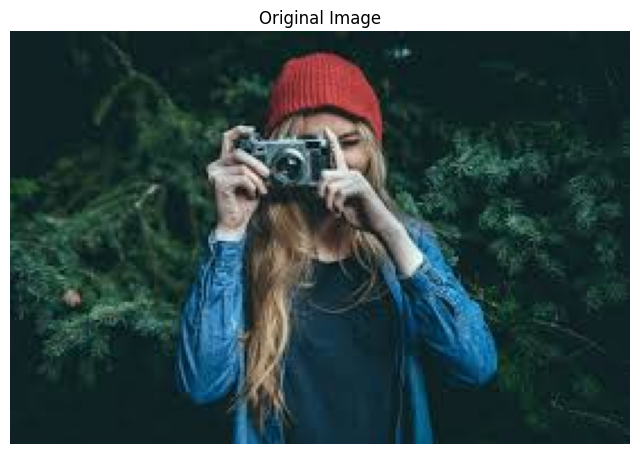

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Make sure to upload an image file (e.g., 'image.jpg') to your Colab environment
# or provide a valid path to an image.
image_path = 'image 2.jpg' # Replace with your image file name

# Load the image
original_image = cv2.imread(image_path)

# Check if the image was loaded successfully
if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # OpenCV loads images in BGR format, convert to RGB for matplotlib display
    rgb_original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    print(f"Image loaded successfully. Dimensions: {original_image.shape}")

    plt.figure(figsize=(8, 6))
    plt.imshow(rgb_original_image)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

### Cropping a Region of Interest (ROI)

To crop an image, you define the coordinates of the region you want to extract. These coordinates typically include the starting row (y), ending row (y + height), starting column (x), and ending column (x + width).

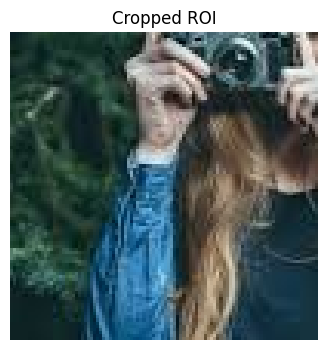

In [2]:
if original_image is not None:
    # Define the ROI coordinates (y_start:y_end, x_start:x_end)
    # Example: crop a 100x100 pixel region starting at (50, 50)
    # You might need to adjust these values based on your image size
    x_start, y_start = 50, 50
    x_end, y_end = 150, 150 # width = 100, height = 100

    # Ensure the ROI coordinates are within the image boundaries
    h, w, _ = original_image.shape
    x_end = min(x_end, w)
    y_end = min(y_end, h)

    # Perform the cropping
    cropped_roi = original_image[y_start:y_end, x_start:x_end]

    # Convert to RGB for display
    rgb_cropped_roi = cv2.cvtColor(cropped_roi, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(rgb_cropped_roi)
    plt.title('Cropped ROI')
    plt.axis('off')
    plt.show()
else:
    print("Original image not loaded. Cannot perform cropping.")

### Copying and Pasting the ROI

Now, let's copy the `cropped_roi` and paste it onto a different location within the `original_image` or onto a new canvas.

In [3]:
if original_image is not None and cropped_roi is not None:
    # Create a copy of the original image to paste the ROI onto
    image_with_pasted_roi = original_image.copy()

    # Define the new location to paste the ROI (top-left corner of the paste region)
    # Example: paste at (200, 200)
    paste_x, paste_y = 200, 200

    # Get the dimensions of the cropped ROI
    roi_h, roi_w, _ = cropped_roi.shape

    # Calculate the end coordinates for pasting
    paste_x_end = paste_x + roi_w
    paste_y_end = paste_y + roi_h

    # Ensure the paste area is within the image boundaries
    img_h, img_w, _ = image_with_pasted_roi.shape

    if paste_x_end <= img_w and paste_y_end <= img_h:
        # Paste the cropped ROI onto the new location
        image_with_pasted_roi[paste_y:paste_y_end, paste_x:paste_x_end] = cropped_roi

        # Convert to RGB for display
        rgb_image_with_pasted_roi = cv2.cvtColor(image_with_pasted_roi, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(rgb_image_with_pasted_roi)
        plt.title(f'Image with ROI pasted at ({paste_x}, {paste_y})')
        plt.axis('off')
        plt.show()
    else:
        print(f"Warning: Paste location ({paste_x},{paste_y}) and ROI size ({roi_w}x{roi_h}) are out of bounds for the image ({img_w}x{img_h}). Adjust paste_x, paste_y or ROI size.")
else:
    print("Original image or cropped ROI not available. Cannot perform pasting.")